This is a companion notebook for the book [Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition?a_aid=keras&a_bid=76564dff). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

This notebook was generated for TensorFlow 2.6.

# Deep learning for timeseries

## Different kinds of timeseries tasks

## A temperature-forecasting example

In [4]:
# !wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
# !unzip jena_climate_2009_2016.csv.zip

**Inspecting the data of the Jena weather dataset**

In [5]:
import os

fname = os.path.join(r"/home/lenovo/Projects/Deep-Learning-Lab/data/source code/jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


**Parsing the data**

In [6]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

**Plotting the temperature timeseries**

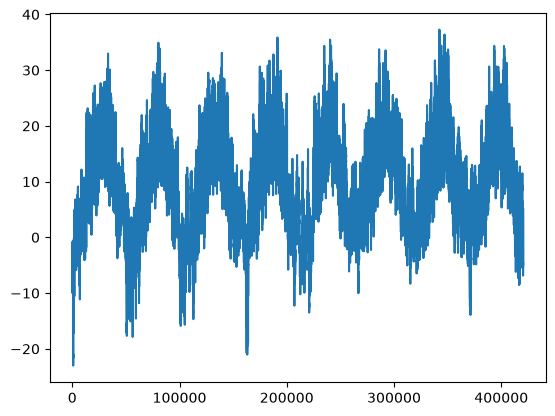

In [7]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

**Plotting the first 10 days of the temperature timeseries**

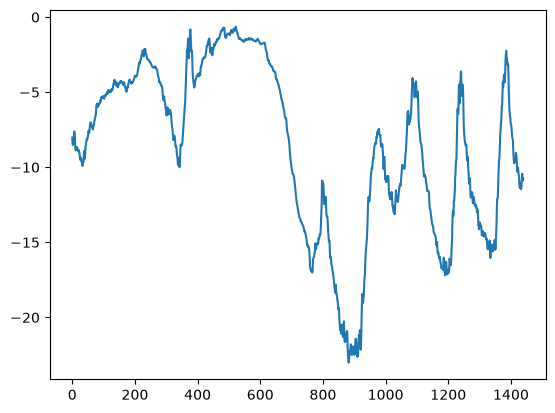

In [8]:
plt.plot(range(1440), temperature[:1440])

**Computing the number of samples we'll use for each data split**

In [9]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


### Preparing the data

**Normalizing the data**

In [10]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [11]:
import numpy as np
from tensorflow import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

I0000 00:00:1788712472.997638    2491 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788712473.749818    2491 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788712473.316149    2491 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


I0000 00:00:1788712477.540433    2491 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


**Instantiating datasets for training, validation, and testing**

In [12]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

**Inspecting the output of one of our datasets**

In [13]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


### A common-sense, non-machine-learning baseline

**Computing the common-sense baseline MAE**

In [14]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


### Let's try a basic machine-learning model

**Training and evaluating a densely connected model**

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


/home/lenovo/Projects/Deep-Learning-Lab/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788712485.462475    4358 service.cc:153] XLA service 0x71bee802fce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788712485.462509    4358 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788712485.502628    4358 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788712485.578848    4358 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788712485.588388    4358

 23/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 38.9518 - mae: 4.8569

I0000 00:00:1788712486.844931    4358 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


818/819 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.0894 - mae: 2.6958

I0000 00:00:1788712492.168950    4358 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10148__.8


819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 12.0870 - mae: 2.6955 - val_loss: 10.0331 - val_mae: 2.4939
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.9444 - mae: 2.3520 - val_loss: 10.3650 - val_mae: 2.5417
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 8.1758 - mae: 2.2524 - val_loss: 10.4305 - val_mae: 2.5623
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7.7191 - mae: 2.1881 - val_loss: 11.2020 - val_mae: 2.6572
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 7.4257 - mae: 2.1470 - val_loss: 11.7142 - val_mae: 2.7061
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 7.2257 - mae: 2.1159 - val_loss: 10.6757 - val_mae: 2.5845
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 6.9975 - mae: 2.0819 - val_loss: 10.7894 - val_mae: 2.5976
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 6.8689 - mae: 2.0639 - val_loss: 11.1596 - val_mae: 2.6407
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step 

**Plotting results**

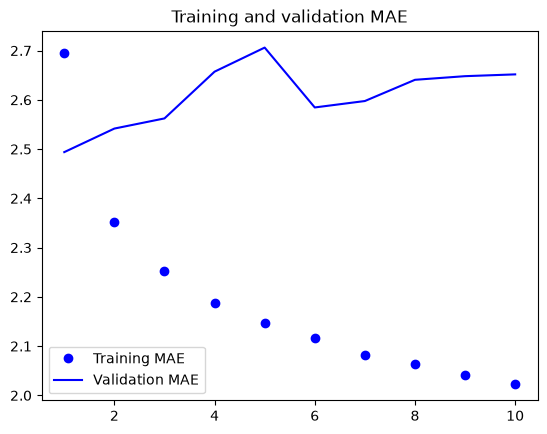

In [16]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Let's try a 1D convolutional model

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 21.9690 - mae: 3.6805 - val_loss: 15.0794 - val_mae: 3.0727
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 15.3660 - mae: 3.1150 - val_loss: 15.2798 - val_mae: 3.0921
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 14.2233 - mae: 2.9912 - val_loss: 14.8266 - val_mae: 3.0441
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 13.3630 - mae: 2.8976 - val_loss: 15.4633 - val_mae: 3.1065
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 12.6368 - mae: 2.8130 - val_loss: 14.5866 - val_mae: 3.0173
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 12.1369 - mae: 2.7557 - val_loss: 14.7294 - val_mae: 3.0238
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 11.7578 - mae: 2.7107 - val_loss: 14.6811 - val_mae: 3.0019
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 11.4172 - mae: 2.6697 - val_loss: 15.7754 - val_mae: 3.1358
Epoch 9/10
819/819 ━━━━━━━━━━

### A first recurrent baseline

**A simple LSTM-based model**

In [18]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 37.4037 - mae: 4.4470 - val_loss: 11.9856 - val_mae: 2.6446
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 10.7835 - mae: 2.5570 - val_loss: 9.8327 - val_mae: 2.4276
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 9.6971 - mae: 2.4268 - val_loss: 9.9370 - val_mae: 2.4283
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 9.3764 - mae: 2.3812 - val_loss: 9.6980 - val_mae: 2.4083
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 9.1003 - mae: 2.3443 - val_loss: 9.4740 - val_mae: 2.3843
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 8.8611 - mae: 2.3153 - val_loss: 9.5945 - val_mae: 2.3907
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 8.6659 - mae: 2.2917 - val_loss: 9.5558 - val_mae: 2.3899
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 8.4807 - mae: 2.2694 - val_loss: 9.7362 - val_mae: 2.4114
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━

## Understanding recurrent neural networks

**NumPy implementation of a simple RNN**

In [19]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.stack(successive_outputs, axis=0)

### A recurrent layer in Keras

**An RNN layer that can process sequences of any length**

In [20]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

**An RNN layer that returns only its last output step**

In [21]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


**An RNN layer that returns its full output sequence**

In [22]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


**Stacking RNN layers**

In [23]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

## Advanced use of recurrent neural networks

### Using recurrent dropout to fight overfitting

**Training and evaluating a dropout-regularized LSTM**

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 342s 414ms/step - loss: 27.4710 - mae: 3.8819 - val_loss: 9.7155 - val_mae: 2.4263
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 319s 390ms/step - loss: 15.0359 - mae: 3.0121 - val_loss: 9.3367 - val_mae: 2.3841
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 327s 399ms/step - loss: 14.3464 - mae: 2.9403 - val_loss: 9.1176 - val_mae: 2.3551
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 314s 383ms/step - loss: 13.7975 - mae: 2.8829 - val_loss: 9.2504 - val_mae: 2.3635
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 320s 391ms/step - loss: 13.4091 - mae: 2.8402 - val_loss: 9.0464 - val_mae: 2.3343
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 339s 414ms/step - loss: 12.9552 - mae: 2.7937 - val_loss: 9.0759 - val_mae: 2.3392
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 390s 476ms/step - loss: 12.6876 - mae: 2.7637 - val_loss: 9.3232 - val_mae: 2.3679
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 326s 398ms/step - loss: 12.4332 - mae: 2.7366 - val_loss: 9.1347 - val_mae: 2.3396
Epoch 9/50
819/8

In [0]:
inputs = keras.Input(shape=(sequence_length, num_features))
x = layers.LSTM(32, recurrent_dropout=0.2, unroll=True)(inputs)

### Stacking recurrent layers

**Training and evaluating a dropout-regularized, stacked GRU model**

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

### Using bidirectional RNNs

**Training and evaluating a bidirectional LSTM**

In [0]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

### Going even further

## Summary